# WeIntern AIML Internship — Week 1 Assignment
### Student Performance Dataset Analysis
**Tasks Covered:** Task 1 (Data Cleaning & Analysis) · Task 2 (Visualizations) · Task 3 (Business Insight Report)

# Task 1

## Dataset Summary
- 205 rows, 12 columns.
- Contains numerical, categorical and identifier columns
- Target variable: FinalScore
- Dataset had missing values, duplicates and inconsistent labels
which were all handled during cleaning.
- Source: Synthetically generated dataset created for
  internship practice purposes using Python's random module.
  It simulates realistic student performance patterns
  including intentional missing values, duplicates,
  and inconsistent labels for cleaning practice.

## Step 1 — Import Libraries

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 — Load and preview the Dataset

In [46]:
df = pd.read_csv("student_performance.csv")

print("\nFirst 5 rows:")
df.head()


First 5 rows:


,StudentID,Name,Gender,Age,AttendancePct,StudyHoursPerWeek,AssignmentScore,MidtermScore,FinalScore,ParentalEducation,InternetAccess,ExtraActivities
0,196,Ananya,F,18,54.3,1.9,30.0,25.0,20.0,No Formal Education,NaN,Yes
1,56,Arjun,M,19,98.7,15.4,60.6,49.3,58.8,High School,No,No
2,79,Karan,Male,17,55.4,4.3,30.0,25.0,20.0,Bachelor's,YES,Yes
3,121,Ananya,female,20,83.4,1.2,30.0,25.0,20.0,Master's,YES,No
4,149,Vivek,male,21,NaN,8.2,33.9,40.3,37.9,PhD,yes,Yes


In [47]:
print("Last 5 rows:")
df.tail()

Last 5 rows:


,StudentID,Name,Gender,Age,AttendancePct,StudyHoursPerWeek,AssignmentScore,MidtermScore,FinalScore,ParentalEducation,InternetAccess,ExtraActivities
200,108,Swati,female,16,90.8,9.2,45.0,44.7,46.9,Master's,YES,No
201,18,Dev,male,17,66.3,11.3,40.7,47.1,36.9,Master's,yes,Yes
202,134,Neha,female,18,58.8,1.9,30.0,25.0,20.0,Bachelor's,YES,No
203,151,Siddharth,male,19,67.8,13.9,51.0,47.9,55.0,No Formal Education,Yes,No
204,160,Harish,Male,21,61.0,14.5,48.9,50.6,46.9,PhD,Yes,No


## Step 3 - Check Shape
### Check dataset shape using number of rows and columns.

In [48]:
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset shape: 205 rows × 12 columns


## Step 4 - Check Info
### Inspect data types using df.info().

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          205 non-null    int64  
 1   Name               205 non-null    object 
 2   Gender             205 non-null    object 
 3   Age                205 non-null    int64  
 4   AttendancePct      194 non-null    float64
 5   StudyHoursPerWeek  193 non-null    float64
 6   AssignmentScore    205 non-null    float64
 7   MidtermScore       205 non-null    float64
 8   FinalScore         205 non-null    float64
 9   ParentalEducation  195 non-null    object 
 10  InternetAccess     200 non-null    object 
 11  ExtraActivities    205 non-null    object 
dtypes: float64(5), int64(2), object(5)
memory usage: 19.3+ KB


## Step 5 — Feature Understanding Table

| Column | Type | Role | Notes |
|--------|------|------|-------|
| StudentID | Identifier | ID only | Not useful for analysis |
| Name | Identifier | ID only | Not useful for analysis |
| Gender | Categorical | Demographic | object dtype |
| Age | Numerical | Demographic | int64, range 16-22 |
| AttendancePct | Numerical | Input Feature | float64, has 11 missing values |
| StudyHoursPerWeek | Numerical | Input Feature | float64, has 12 missing values |
| AssignmentScore | Numerical | Performance | float64, score 0-100 |
| MidtermScore | Numerical | Performance | float64, score 0-100 |
| FinalScore | Numerical | TARGET variable | float64, main outcome |
| ParentalEducation | Categorical | Background | object, has 10 missing values |
| InternetAccess | Categorical | Resource | object, has 5 missing values |
| ExtraActivities | Categorical | Engagement | object, Yes/No |

## Step 6 — Check Missing Values.

In [50]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

print(missing_report[missing_report["Missing Count"] > 0])

                   Missing Count  Missing %
AttendancePct                 11       5.37
StudyHoursPerWeek             12       5.85
ParentalEducation             10       4.88
InternetAccess                 5       2.44


In [51]:
# Total missing values in entire dataset
print(f"Total missing values: {missing.sum()}")

Total missing values: 38


## Step 7 - Check for duplicated rows.

In [52]:
# Count duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 5


In [53]:
# Remove duplicate rows
df = df.drop_duplicates()

print(f"Rows before: 205")
print(f"Rows after : {df.shape[0]}")

Rows before: 205
Rows after : 200


## Step 8 - Check Inconsistent Labels.


In [54]:
# Get all categorical columns
cat_cols = df.select_dtypes(include="object").columns

# Loop through each one and print unique values
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")
    print()

Name: ['Ananya' 'Arjun' 'Karan' 'Vivek' 'Vikram' 'Divya' 'Manish' 'Neha' 'Meera'
 'Raj' 'Dev' 'Nikhil' 'Harish' 'Rahul' 'Rohan' 'Piyush' 'Riya' 'Ravi'
 'Swati' 'Simran' 'Aarav' 'Amit' 'Kavya' 'Pooja' 'Tanvi' 'Komal' 'Sakshi'
 'Nisha' 'Sneha' 'Preeti' 'Naveen' 'Aditi' 'Isha' 'Anjali' 'Suresh'
 'Siddharth' 'Shreya' 'Arun' 'Deepak' 'Priya']

Gender: ['F' 'M' 'Male' 'female' 'male' 'Female']

ParentalEducation: ['No Formal Education' 'High School' "Bachelor's" "Master's" 'PhD' nan]

InternetAccess: [nan 'No' 'YES' 'yes' 'Yes']

ExtraActivities: ['Yes' 'No']



# Data Cleaning

## Step 9 — Standardize Inconsistent Labels.

In [55]:
# Step 1 — make everything lowercase first (removes case differences)
df["Gender"] = df["Gender"].str.strip().str.lower()
df["InternetAccess"] = df["InternetAccess"].str.strip().str.lower()

# Step 2 — now replace everything to a standard label
df["Gender"] = df["Gender"].replace({"m": "Male", "male": "Male",
                                      "f": "Female", "female": "Female"})

df["InternetAccess"] = df["InternetAccess"].replace({"yes": "Yes", "no": "No"})

# Verification
print("Gender values after:", df["Gender"].unique())
print("InternetAccess values after:", df["InternetAccess"].unique())

Gender values after: ['Female' 'Male']
InternetAccess values after: [nan 'No' 'Yes']


## After Standardisation

In [56]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")
    print()

Name: ['Ananya' 'Arjun' 'Karan' 'Vivek' 'Vikram' 'Divya' 'Manish' 'Neha' 'Meera'
 'Raj' 'Dev' 'Nikhil' 'Harish' 'Rahul' 'Rohan' 'Piyush' 'Riya' 'Ravi'
 'Swati' 'Simran' 'Aarav' 'Amit' 'Kavya' 'Pooja' 'Tanvi' 'Komal' 'Sakshi'
 'Nisha' 'Sneha' 'Preeti' 'Naveen' 'Aditi' 'Isha' 'Anjali' 'Suresh'
 'Siddharth' 'Shreya' 'Arun' 'Deepak' 'Priya']

Gender: ['Female' 'Male']

ParentalEducation: ['No Formal Education' 'High School' "Bachelor's" "Master's" 'PhD' nan]

InternetAccess: [nan 'No' 'Yes']

ExtraActivities: ['Yes' 'No']



## Step 10 — Fill Missing Values

In [57]:
# Numerical columns → fill with median
for col in ["StudyHoursPerWeek", "AttendancePct"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled '{col}' with median: {median_val:.2f}")

# Categorical columns → fill with 'Unknown'
for col in ["ParentalEducation", "InternetAccess"]:
    df[col] = df[col].fillna("Unknown")
    print(f"Filled '{col}' with 'Unknown'")

Filled 'StudyHoursPerWeek' with median: 10.90
Filled 'AttendancePct' with median: 69.90
Filled 'ParentalEducation' with 'Unknown'
Filled 'InternetAccess' with 'Unknown'


### verify that all missing values are actually gone

In [58]:
print(df.isnull().sum())

StudentID            0
Name                 0
Gender               0
Age                  0
AttendancePct        0
StudyHoursPerWeek    0
AssignmentScore      0
MidtermScore         0
FinalScore           0
ParentalEducation    0
InternetAccess       0
ExtraActivities      0
dtype: int64


## Step 11 — Rename columns

In [59]:
# Check current column names
print(df.columns.tolist())

['StudentID', 'Name', 'Gender', 'Age', 'AttendancePct', 'StudyHoursPerWeek', 'AssignmentScore', 'MidtermScore', 'FinalScore', 'ParentalEducation', 'InternetAccess', 'ExtraActivities']


### All column names are clear and descriptive. No renaming required.

## Step 12 — Convert Data Types

In [60]:
# Check current data types
print(df.dtypes)

StudentID              int64
Name                  object
Gender                object
Age                    int64
AttendancePct        float64
StudyHoursPerWeek    float64
AssignmentScore      float64
MidtermScore         float64
FinalScore           float64
ParentalEducation     object
InternetAccess        object
ExtraActivities       object
dtype: object


### All columns have appropriate data types. No conversion required.

## Step 13 — Save the Cleaned Dataset

In [61]:
df.to_csv("student_performance_cleaned.csv", index=False)
print("Cleaned dataset saved!")

Cleaned dataset saved!


## Assumptions Made During Cleaning

1. Missing numerical values (AttendancePct, StudyHoursPerWeek)
   were filled with median — assumed median best represents
   a typical student without being affected by outliers.

2. Missing categorical values (ParentalEducation, InternetAccess)
   were filled with 'Unknown' — assumed it is better to honestly
   label missing data than guess a category.

3. Duplicate rows were removed keeping the first occurrence —
   assumed they were data entry errors, not real students.

4. Inconsistent gender labels (M, male, Male) were standardized
   to Male/Female — assumed they all refer to the same categories.

5. Original dataset was kept unchanged and a separate cleaned
   version was saved — assumed raw data should always be preserved.

6. Column names were assumed to be clear and descriptive
   enough — no renaming was required.

7. All column data types were assumed to be correct
   (int64, float64, object) — no type conversion was required.

## Step 14 - Descriptive Statistics

In [62]:
df.describe().round(2)

,StudentID,Age,AttendancePct,StudyHoursPerWeek,AssignmentScore,MidtermScore,FinalScore
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,100.50,19.10,70.09,10.32,38.88,37.62,36.74
std,57.88,2.03,16.37,5.45,9.18,10.38,10.86
min,1.00,16.00,40.40,1.10,30.00,25.00,20.00
25%,50.75,17.00,56.60,5.40,30.00,27.15,28.08
50%,100.50,19.00,69.90,10.90,35.90,37.00,36.95
75%,150.25,21.00,82.88,14.58,45.02,44.90,44.82
max,200.00,22.00,99.80,19.70,67.20,63.20,66.10


### NumPy Analysis of Final Scores

In [63]:
scores_np = np.array(df["FinalScore"])
print(f"NumPy Mean  : {np.mean(scores_np):.2f}")
print(f"NumPy Std   : {np.std(scores_np):.2f}")
print(f"NumPy Min   : {np.min(scores_np):.2f}")
print(f"NumPy Max   : {np.max(scores_np):.2f}")

NumPy Mean  : 36.74
NumPy Std   : 10.84
NumPy Min   : 20.00
NumPy Max   : 66.10


## Step 15 — Group Comparisons
### Analysing how different groups perform on FinalScore

In [64]:
print("Average Final Score by Internet Access:")
print(df.groupby("InternetAccess")["FinalScore"].mean().round(2).to_frame())
print()
print("Average Final Score by Extra Activities:")
print(df.groupby("ExtraActivities")["FinalScore"].mean().round(2).to_frame())
print()
print("Average Final Score by Gender:")
print(df.groupby("Gender")["FinalScore"].mean().round(2).to_frame())

Average Final Score by Internet Access:
                FinalScore
InternetAccess            
No                   36.35
Unknown              41.54
Yes                  36.68

Average Final Score by Extra Activities:
                 FinalScore
ExtraActivities            
No                    36.78
Yes                   36.71

Average Final Score by Gender:
        FinalScore
Gender            
Female       36.25
Male         37.24


## Observations from Descriptive Statistics

1. The average final score is 36.74 out of 100, suggesting overall
   academic performance is below average across the dataset.

2. Attendance ranges from 40% to 99.8%, showing a wide gap between
   the most and least attending students.

3. Study hours range from 1.1 to 19.7 hours per week, indicating
   some students study significantly more than others.

4. The median final score (36.95) is very close to the mean (36.74),
   suggesting the score distribution is fairly balanced without
   extreme outliers pulling it in either direction.

5. Assignment scores start at a minimum of 30, while final scores
   go as low as 20, suggesting some students perform worse in
   finals than in assignments.

6. 25% of students attend less than 56.6% of classes, which is
   quite low and may negatively impact their final scores.

7. Study hours average 10.32 per week — students in the top 25%
   study 14.58+ hours, nearly 3x more than the bottom 25% at 5.4 hours.

8. Students with internet access (36.68) scored slightly higher
   than those without (36.35), though the difference is small
   and may not be significant.

9. Extra activities show almost no difference in final scores
   (Yes: 36.71 vs No: 36.78), suggesting participation in
   extra activities neither helps nor hurts academic performance
   in this dataset.

10. Students with 'Unknown' internet access status scored highest
    on average (41.54), however this group is very small (missing
    values filled as Unknown), so this result is likely unreliable
    and should not be interpreted as a real pattern.

# Task 2 — Data Visualization Project

## Objective
Transform the cleaned student performance dataset into
meaningful visualizations to identify patterns, trends
and relationships between variables.

In [65]:
df = pd.read_csv("student_performance_cleaned.csv")
print(f"Cleaned dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Cleaned dataset loaded: 200 rows × 12 columns


In [66]:
# Make charts appear inside the notebook
%matplotlib inline

# Clean style for all charts
sns.set_theme(style="whitegrid", palette="muted")

print("Visualization setup done!")

Visualization setup done!


In [67]:
import os
os.makedirs("outputs/charts", exist_ok=True)
print("Folders created!")

Folders created!


## Chart 1 — Distribution of Final Scores (Histogram)

A histogram shows how scores are spread across all students.
- X-axis = score range
- Y-axis = number of students
- A peak in the middle = most students score around average

In [68]:
print(df["FinalScore"].describe())
print(df["FinalScore"].value_counts(bins=15).sort_index())

count    200.000000
mean      36.744000
std       10.863385
min       20.000000
25%       28.075000
50%       36.950000
75%       44.825000
max       66.100000
Name: FinalScore, dtype: float64
(19.953, 23.073]    30
(23.073, 26.147]    13
(26.147, 29.22]     15
(29.22, 32.293]     14
(32.293, 35.367]    19
(35.367, 38.44]     17
(38.44, 41.513]     23
(41.513, 44.587]    18
(44.587, 47.66]     19
(47.66, 50.733]     11
(50.733, 53.807]     9
(53.807, 56.88]      6
(56.88, 59.953]      4
(59.953, 63.027]     1
(63.027, 66.1]       1
Name: count, dtype: int64


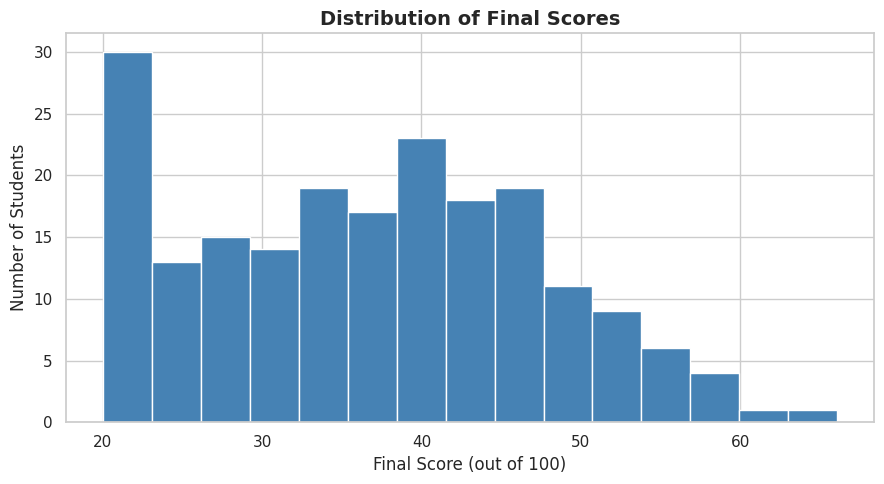

In [69]:
plt.figure(figsize=(9, 5))
plt.hist(df["FinalScore"], bins=15, color="steelblue", edgecolor="white")
plt.title("Distribution of Final Scores", fontsize=14, fontweight="bold")
plt.xlabel("Final Score (out of 100)")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("outputs/charts/score_distribution.png", dpi=150)
plt.show()

### Observation — Distribution of Final Scores

The histogram displays the distribution of final scores across
200 students. Most students scored in the 20–23 range, with
frequency gradually decreasing as scores increase. Only a few
students achieved scores between 55–65. The distribution is
right skewed, with the tail extending toward higher scores,
indicating that high scorers are rare in this dataset. This
pattern is strong and clearly visible.

**Possible Reasons:**
- Low attendance among students
- Insufficient study hours or exam preparation
- Difficult exam level
- Differences in student learning abilities

## Chart 2 — Student Count by Gender (Count Plot)

A count plot shows how many students fall into each category.
Here we check if the dataset is balanced between male and
female students.

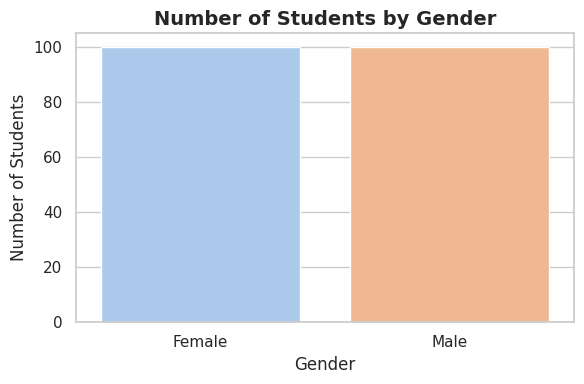

In [70]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", data=df, hue="Gender", palette="pastel", legend=False)
plt.title("Number of Students by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("outputs/charts/gender_distribution.png", dpi=150)
plt.show()

### Observation — Number of Students by Gender

The count plot shows that there are approximately 100 Female
students and 100 Male students. The dataset is well balanced,
with neither gender significantly outnumbering the other.
Gender balance is important because it helps reduce bias and
ensures that analysis results are fair and representative
of both groups. The pattern is clear and strong. Since both
groups are equal in size, any difference in performance
between genders cannot be attributed to sample size imbalance.

## Chart 3 — Final Score by Extra Activities (Box Plot)

A box plot shows the median, spread and outliers for each group.
- The line in the middle of the box = median score
- The box itself = where the middle 50% of students fall
- Dots outside the box = outliers (unusually high or low scorers)

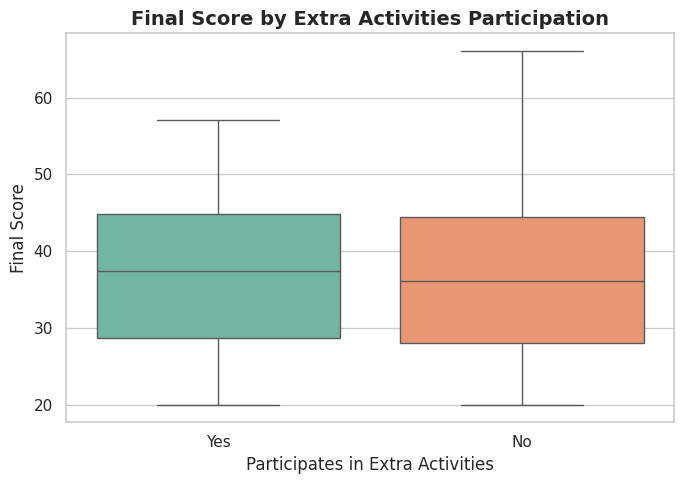

In [71]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="ExtraActivities", y="FinalScore",
            data=df, hue="ExtraActivities", palette="Set2", legend=False)
plt.title("Final Score by Extra Activities Participation",
          fontsize=14, fontweight="bold")
plt.xlabel("Participates in Extra Activities")
plt.ylabel("Final Score")
plt.tight_layout()
plt.savefig("outputs/charts/score_by_activities.png", dpi=150)
plt.show()

### Observation — Final Score by Extra Activities

The box plot compares the final scores of students who participate
in extra activities and those who do not. The median final score
of students who participate in extra activities is 36.71, while
the median score of students who do not participate is 36.78.
Both groups have nearly identical median scores and similar box
sizes, indicating that the distribution and variability of scores
are very similar. The difference between the two groups is
extremely small, suggesting a weak relationship between extra
activity participation and academic performance in this dataset.
This may be because students are able to balance extracurricular
activities with their studies, and other factors such as
attendance, study hours, and individual learning habits have a
greater impact on final scores.

## Chart 4 — Study Hours vs Final Score (Scatter Plot)

A scatter plot shows the relationship between two numeric variables.
- Each dot = one student
- An upward trend = more study hours linked to higher scores
- A flat or random spread = weak relationship

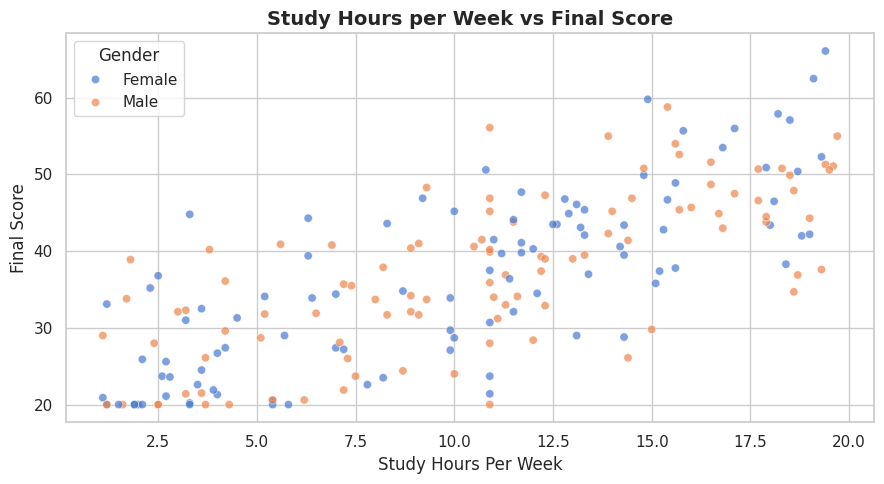

In [72]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x="StudyHoursPerWeek", y="FinalScore",
                hue="Gender", data=df, alpha=0.7)
plt.title("Study Hours per Week vs Final Score",
          fontsize=14, fontweight="bold")
plt.xlabel("Study Hours Per Week")
plt.ylabel("Final Score")
plt.tight_layout()
plt.savefig("outputs/charts/study_vs_score.png", dpi=150)
plt.show()

### Observation — Study Hours per Week vs Final Score

The scatter plot shows the relationship between Study Hours
per Week and Final Score. As study hours increase, final
scores generally tend to increase, indicating a positive
correlation between studying and academic performance. The
trend is moderately strong because the points show a clear
upward pattern, although there is some variation among
students. Male and female students are distributed similarly
across the graph, suggesting that gender does not significantly
affect the relationship between study hours and final scores.
A few students who study many hours still achieve relatively
low scores, indicating that factors such as attendance,
learning methods, motivation, and exam difficulty may also
influence academic performance.

## Chart 5 — Attendance % vs Final Score (Scatter Plot)

This chart specifically examines whether higher attendance
is associated with better final scores — one of the key
trend questions for this dataset.

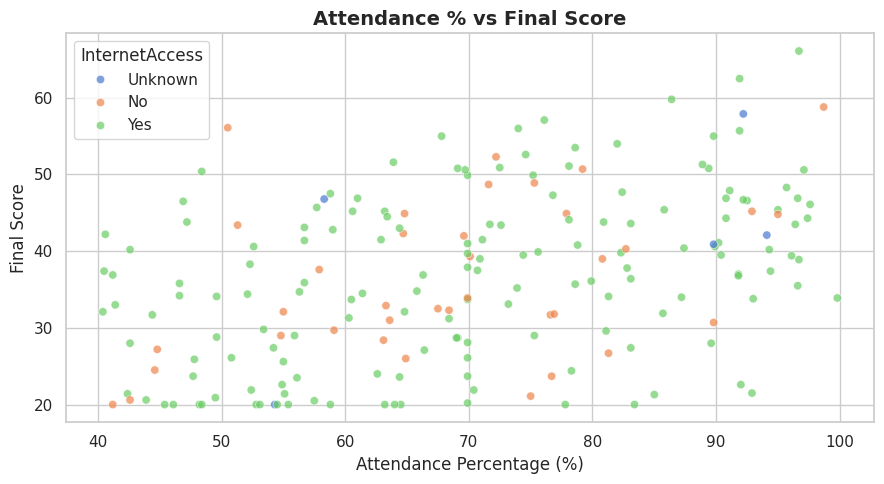

In [73]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x="AttendancePct", y="FinalScore",
                hue="InternetAccess", data=df, alpha=0.7)
plt.title("Attendance % vs Final Score",
          fontsize=14, fontweight="bold")
plt.xlabel("Attendance Percentage (%)")
plt.ylabel("Final Score")
plt.tight_layout()
plt.savefig("outputs/charts/attendance_vs_score.png", dpi=150)
plt.show()

### Observation — Attendance % vs Final Score

The scatter plot shows the relationship between Attendance
Percentage (%) and Final Score, with points colored according
to Internet Access. As attendance percentage increases, final
scores generally tend to increase, indicating a positive
relationship between attendance and academic performance.
However, the points are fairly spread out, so the trend is
moderate rather than very strong. Students with higher
attendance often achieve better scores, but there are also
some students with high attendance and average scores, as
well as a few students with lower attendance who perform
relatively well. The data points for different internet
access categories overlap considerably, suggesting that
attendance has a more noticeable relationship with final
scores than internet access in this graph. A possible reason
for this trend is that students who attend classes more
regularly are exposed to more instruction, participate in
discussions, and stay up to date with coursework, which can
contribute to better academic performance.

## Chart 6 — Correlation Heatmap

A heatmap shows how strongly every numeric variable relates
to every other variable.
- Values close to +1.0 = strong positive relationship
- Values close to 0.0 = no relationship
- Values close to -1.0 = opposite relationship

Look at the FinalScore row/column — variables with high
values there are the strongest predictors of final score.

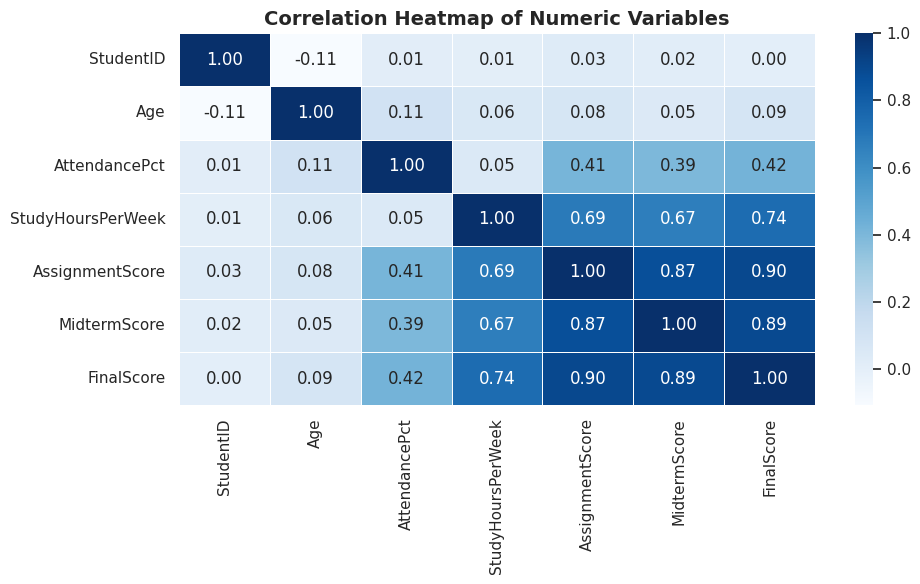

In [74]:
numeric_cols = df.select_dtypes(include="number")
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="Blues", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/charts/correlation_heatmap.png", dpi=150)
plt.show()

### Observation — Correlation Heatmap of Numeric Variables

The heatmap shows relationships between all numeric variables.
AssignmentScore (0.90) and MidtermScore (0.89) have the
strongest positive correlation with FinalScore, meaning
students who perform well in assignments and midterms
consistently score higher in finals. StudyHoursPerWeek
also shows a strong correlation (0.74), while Age and
StudentID show negligible correlations close to zero.

One weak negative correlation exists between StudentID
and Age (-0.11), but it is too small to be meaningful.

Importantly, correlation does not imply causation — a
high correlation between study hours and final score does
not mean studying alone causes better performance. Other
factors like attendance, motivation, and teaching quality
also play a role.

# Task 3 — Business Insight Report

## 1. Title
Student Performance Dataset — Business Insight Report
WeIntern AIML Internship — Week 1

---

## 2. Objective
To analyze a student performance dataset and identify key
factors that influence academic outcomes, with actionable
recommendations for academic support teams and educators.

---

## 3. Dataset Summary
- Total students analyzed: 200 (after removing 5 duplicates)
- Total features: 12 columns
- Target variable: FinalScore (0–100)
- Source: Synthetically generated dataset simulating realistic
  student performance patterns
- Data issues found and resolved: missing values, duplicate rows,
  and inconsistent categorical labels

---

## 4. Analysis Approach
- Loaded and inspected raw data using Pandas
- Standardized inconsistent categorical labels (Gender, InternetAccess)
- Filled missing numeric values with column medians
- Filled missing categorical values with 'Unknown'
- Computed descriptive statistics using NumPy and Pandas
- Created 6 visualizations using Matplotlib and Seaborn
- Computed correlation matrix for all numeric variables
- Performed group comparisons by Gender, InternetAccess and ExtraActivities

---

## 5. Key Findings

**Finding 1 — Attendance is positively linked to performance**
Students with higher attendance percentages tend to cluster
around higher final scores, as visible in the attendance vs
final score scatter plot. This is one of the most consistent
patterns observed across the dataset.

**Finding 2 — Study hours show a strong positive relationship**
The scatter plot reveals a moderately strong positive correlation
(r = 0.74) between weekly study hours and final scores. Students
studying more hours generally perform better, although some
high-study students still scored below average, suggesting other
factors also play a role.

**Finding 3 — Assignment scores are the strongest predictor**
AssignmentScore shows the highest correlation with FinalScore
(r = 0.90), making consistent assignment completion the most
reliable early indicator of final academic performance.

**Finding 4 — Extra activities show negligible impact**
Students participating in extra activities scored 36.71 on
average vs 36.78 for those who did not — a difference too
small to be meaningful. Extra activities neither significantly
help nor hurt academic performance.

**Finding 5 — Score distribution is right skewed**
Most students scored in the 20–23 range, with very few achieving
above 55. This suggests overall underperformance across the
dataset, which may reflect exam difficulty or insufficient
preparation.

**Finding 6 — Gender shows minimal performance difference**
Female students averaged 36.25 vs Male students at 37.24.
The small difference suggests gender is not a significant
driver of academic performance in this dataset.

**Finding 7 — Internet access shows a small performance gap**
Students with internet access averaged 36.68 vs 36.35 for
those without. While small, this gap may reflect unequal
access to study resources.

---

## 6. Recommendations

**R1. Introduce an attendance alert system**
Flag students whose attendance drops below 75% for early
intervention by academic advisors, as attendance shows a
consistent positive relationship with final scores.

**R2. Promote structured study programs**
Students studying 10+ hours weekly perform noticeably better.
Introducing study groups or scheduled library sessions could
help lower-performing students improve.

**R3. Track assignment completion as an early warning signal**
Since assignment scores correlate most strongly with final
scores (r = 0.90), declining assignment performance should
trigger proactive academic support immediately.

**R4. Address the digital divide**
Students without internet access underperform slightly on
average. Providing school computer lab access or Wi-Fi
support programs could help reduce this gap.

**R5. Improve data collection quality**
Several columns had missing values during analysis. Consistent
collection of parental education and internet access data
would enable deeper and more reliable analysis in future cycles.

---

## 7. Limitations
- This is a synthetically generated dataset; findings should
  be validated on real institutional data before acting on them
- Correlation does not imply causation — higher attendance may
  reflect student motivation rather than directly causing
  better performance
- External factors such as home environment, health, and
  teaching quality are not captured in this dataset
- Sample size of 200 students limits generalizability to
  larger populations

---

## 8. Conclusion
Attendance percentage and assignment completion are the two
most actionable indicators of student academic performance
based on this dataset. Early identification of disengaged
students — tracked through attendance drops and assignment
submission patterns — could enable timely, targeted
interventions. Improving data collection practices will be
essential for more robust analysis in future academic cycles.